In [64]:
from langgraph.store.memory import InMemoryStore
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
import uuid
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.base import BaseStore
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.runnables import RunnableConfig

In [65]:
load_dotenv()

True

In [66]:
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

store = InMemoryStore(index= {"embed": embeddings, "dims": 768})

In [67]:
# folder in the database user/rathan/details
user_id = "rathan"
namespace = ("user", user_id, "details")

In [68]:
# namespace = path in the database
# key = filename in the database
# value = actual data store in the db

random_id = str(uuid.uuid4())

store.put(namespace=namespace, key=random_id, value={"data": "My name is Rathan"})

In [69]:
store.put(namespace, str(uuid.uuid4()), {"data": "Profession: Teaches AI on YouTube"})
store.put(namespace, str(uuid.uuid4()), {"data": "Prefers concise answers"})
store.put(namespace, str(uuid.uuid4()), {"data": "Likes examples in Python"})
store.put(namespace, str(uuid.uuid4()), {"data": "Building MCP servers (Python-based project)"})

In [70]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user's preferences, context, and past interactions.

If the user's name or relevant personal context is available, always personalize your responses by:
    - Always Address the user by name (e.g., "Sure, rathan...") when appropriate
    - Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    - Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    - Greetings and transitions
    - Help or guidance tailored to tools and frameworks the user uses
    - Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user's memory (which may be empty) is provided as: {user_details_content}
"""

In [71]:
llm = ChatGoogleGenerativeAI(model='models/gemini-2.5-flash')

In [72]:
def memorize(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")
    
    items = store.search(namespace)

    if items:
        facts = "\n".join([item.value["data"] for item in items])
    else:
        facts = "You don't know anything about this user yet."

    print(f"Retrieved: {facts}")
    final_prompt = SYSTEM_PROMPT_TEMPLATE.format(user_details_content=facts)
    
    # We return this as a SystemMessage to silently inject it into the conversation
    return {"messages": [SystemMessage(content = final_prompt)]}

In [73]:
def chat_node(state: MessagesState):
    response = llm.invoke(state['messages'])
    return {"messages": response}

In [74]:
graph = StateGraph(MessagesState)

graph.add_node("memorize", memorize)
graph.add_node("chat", chat_node)

graph.add_edge(START, "memorize")
graph.add_edge("memorize", "chat")
graph.add_edge("chat", END)

workflow = graph.compile(store=store)

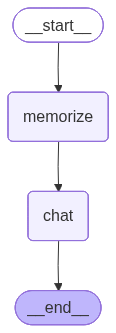

In [75]:
workflow

In [76]:
config = {"configurable": {"user_id": "rathan"}}

workflow.invoke({"messages": [{"role": "user", "content": "tell about langgraph"}]}, config=config)

Retrieved: My name is Rathan
Profession: Teaches AI on YouTube
Prefers concise answers
Likes examples in Python
Building MCP servers (Python-based project)


{'messages': [HumanMessage(content='tell about langgraph', additional_kwargs={}, response_metadata={}, id='2622f798-cf75-4add-b532-42d0f385f1ba'),
  SystemMessage(content='You are a helpful assistant with memory capabilities.\nIf user-specific memory is available, use it to personalize \nyour responses based on what you know about the user.\n\nYour goal is to provide relevant, friendly, and tailored \nassistance that reflects the user\'s preferences, context, and past interactions.\n\nIf the user\'s name or relevant personal context is available, always personalize your responses by:\n    - Always Address the user by name (e.g., "Sure, rathan...") when appropriate\n    - Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")\n    - Adjusting the tone to feel friendly, natural, and directly aimed at the user\n\nAvoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." \nsay "Since your project is b